# Coupled X_e and T_e: spectroxide against DarkHistory

ADR 0009 made the solver evolve the hydrogen ionization fraction X_H alongside the
electron temperature T_e below z ≈ 1575. The existing checks of the heated case compare
against `dev/scripts/heatloss/coupled_xe_expectation.py`, which we wrote ourselves. This
notebook compares against an independent code: the three-level-atom (TLA) integrator of
DarkHistory (Liu, Ridgway & Slatyer 2020, arXiv:1904.09296; `darkhistory.history.tla.get_history`,
v1.1.2 from PyPI; `pip install darkhistory`, no data files needed). Output: the paper figure
`notebooks/figures/xe_darkhistory_comparison.pdf` (Appendix `app:xe`) and the numbers quoted
there, in `dev/data/xe_darkhistory_comparison.json`. Runtime about one minute.

**What this checks.** Both codes solve the same model: the Peebles TLA with the case-B
coefficient α_B evaluated at the gas temperature T_m, photoionization at the radiation
temperature T_r, and the RECFAST matter-temperature equation with an external heating term.
DarkHistory integrates the two ODEs with LSODA; spectroxide advances X_H by a split step
alongside the PDE's backward-Euler T_e update. Agreement tests our implementation of the
coupled equations: the split, the step cap, the heating bookkeeping, and the heat capacity.

**What this does not check.** DarkHistory uses the same Péquignot et al. (1991) α_B fit and
the same fudge factor 1.125 (`physics.alpha_recomb`). The comparison says nothing about
whether that fit holds at high T_m, nor about collisional ionization, which neither code
includes. The heating histories below keep T_m below 1e4 K except for the one case labeled
"hot".

**Matching the codes.** DarkHistory differs from spectroxide in three inputs that are not
part of the coupling. We patch the first two and match the third, so the comparison isolates
the coupling:

1. Background: DarkHistory uses astropy's Planck18 with photons only in Ω_r (no
   neutrinos). We replace `hubble` and `dtdz` with spectroxide's H(z) for its `planck2018`
   preset, and set n_H, n_He/n_H, and T_CMB = 2.7255 K to match.
2. Hydrogen binding energy: DarkHistory uses the infinite-mass Rydberg (13.6057 eV);
   spectroxide uses the reduced-mass value (13.5983 eV) and the measured Lyman-α wavelength.
3. Start: both codes start at z = 1450 with ρ_e = T_m/T_r = 1 and X_H from spectroxide's
   standard table. DarkHistory's Saha-to-TLA switch at z = 1500 stalls LSODA when started
   above it.

Both codes divide the Sobolev Lyman-α escape rate by RECFAST 1.5.2's two Gaussian
corrections, fitted together with F = 1.125 (spectroxide since ADR 0011), so DarkHistory's
own `peebles_C` runs unmodified.

Section 2 also runs DarkHistory with only the background matched, to show the size of
item 2.

In [1]:
import json
import subprocess
import tempfile
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import darkhistory
import darkhistory.physics as phys
from darkhistory.history import tla

from spectroxide import apply_style, C, DOUBLE_COL
from spectroxide.plot_params import LW, LW_THIN, MS_SMALL, ANNOT_SIZE, LW_AXIS
from spectroxide.cosmology import Cosmology, hubble, ionization_fraction
from spectroxide.cosmology import _cosmo_n_h  # hydrogen density [m^-3]

apply_style()
warnings.filterwarnings("ignore", category=RuntimeWarning, module="darkhistory")

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / "notebooks" / "figures"
DATA_OUT = PROJECT_ROOT / "dev" / "data" / "xe_darkhistory_comparison.json"
BIN = PROJECT_ROOT / "target" / "release" / "spectroxide"

XE_HISTORY = PROJECT_ROOT / "target" / "release" / "examples" / "xe_history"
subprocess.run(["cargo", "build", "--release", "--bin", "spectroxide", "--example", "xe_history"],
               cwd=PROJECT_ROOT, check=True, capture_output=True)
PHYSICS_HASH = subprocess.run([BIN, "physics-hash"], capture_output=True,
                              text=True, check=True).stdout.strip()
print("spectroxide physics hash:", PHYSICS_HASH)
print("DarkHistory:", Path(darkhistory.__file__).parent)

spectroxide physics hash: b7ee000eaf5ea10a
DarkHistory: /home/bakerem/miniforge3/lib/python3.10/site-packages/darkhistory


## 1. Matching DarkHistory to spectroxide's inputs

In [2]:
COSMO = Cosmology.planck2018()
CD = COSMO.to_dict()
T0 = CD["t_cmb"]                     # K
KB_EV = 8.617333262e-5               # eV/K (CODATA 2018)
HBARC = 1.973269804e-5               # eV cm
F_HE = CD["y_p"] / (4.0 * (1.0 - CD["y_p"]))
E_H = 13.605693122994 / (1.0 + 9.1093837015e-31 / 1.67262192369e-27)  # reduced mass, eV
Z_START = 1450.0

_ORIG = {k: getattr(phys, k) for k in
         ["nH", "chi", "TCMB", "hubble", "dtdz", "rydberg", "lya_eng", "lya_freq"]}


def configure_darkhistory(atomic=True):
    # Background always matched; atomic=True also matches item 2.
    for k, v in _ORIG.items():
        setattr(phys, k, v)
    phys.nH = _cosmo_n_h(0.0, CD) * 1e-6          # cm^-3 today
    phys.chi = F_HE
    phys.TCMB = lambda rs: T0 * KB_EV * rs          # eV
    phys.hubble = lambda rs, *a, **k: hubble(rs - 1.0, CD)
    phys.dtdz = lambda rs, *a, **k: -1.0 / (rs * hubble(rs - 1.0, CD))
    if atomic:
        phys.rydberg = E_H
        phys.lya_eng = 0.75 * E_H
        phys.lya_freq = phys.lya_eng / (2 * np.pi * phys.hbar)


def rho_gamma(z):
    # Photon energy density [eV cm^-3].
    t = T0 * KB_EV * (1.0 + z)
    return np.pi**2 / 15.0 * t**4 / HBARC**3


def dh_history(dq_dz, z_out, rtol=1e-9):
    # X_e and rho_e = T_m / T_r from DarkHistory at the redshifts z_out (descending).
    # dq_dz is d(Δρ_γ/ρ_γ)/dz, the same function spectroxide receives; DarkHistory takes
    # the heating rate per volume, dE/dV dt = dq_dz · ρ_γ · H (1+z), all of it into heat.
    rs = np.concatenate([[1.0 + Z_START], 1.0 + np.asarray(z_out)])
    x0 = float(ionization_fraction(Z_START, CD))
    init = [phys.TCMB(1.0 + Z_START), x0, 0.0, 0.0]
    inj = lambda r: dq_dz(r - 1.0) * rho_gamma(r - 1.0) * hubble(r - 1.0, CD) * r
    s = tla.get_history(rs, init_cond=init, f_heating=1.0, injection_rate=inj,
                        rtol=rtol, mxstep=200000)
    xe = s[1:, 1] + s[1:, 2] + 2.0 * s[1:, 3]
    return xe, s[1:, 0] / phys.TCMB(rs[1:])


DZ_FINE = 0.25


def sx_history(dq_dz, z_out, dz_snap=0.0, fixed=False):
    # X_e and rho_e from one spectroxide PDE run from Z_START, via examples/xe_history.rs.
    # dz_snap > 0 adds snapshots every dz_snap in z, which caps the step at dz_snap;
    # dz_snap = 0 keeps the solver's own steps (0.005 z below z_switch, ADR 0009).
    zt = np.geomspace(max(0.9 * min(z_out), 10.0), 1.1 * Z_START, 4000)
    with tempfile.NamedTemporaryFile("w", suffix=".csv", delete=False) as f:
        f.write("z,dq_dz\n")
        for z in zt:
            f.write(f"{z:.12e},{dq_dz(z):.12e}\n")
    cmd = [XE_HISTORY, f.name, str(Z_START), ",".join(f"{z:g}" for z in z_out), str(dz_snap)]
    if fixed:
        cmd.append("--fixed-ionization")
    out = subprocess.run(cmd, capture_output=True, text=True, check=True).stdout
    Path(f.name).unlink()
    rows = np.loadtxt(out.splitlines()[1:], delimiter=",", ndmin=2)
    return rows[:, 1], rows[:, 2]

## 2. No heating

Both codes should reproduce the same recombination history. Below z ≈ 500 the gas cools
below T_r, α_B(T_m) grows, and X_e falls below the standard table, which evaluates α_B at T_r.

In [3]:
Z_DH = np.geomspace(1440.0, 200.0, 300)
Z_SX = np.array([1400, 1300, 1200, 1100, 1000, 950, 900, 850, 800, 700,
                 600, 500, 400, 300, 250, 200], dtype=float)
null = lambda z: 0.0

configure_darkhistory(atomic=False)
xe_dh_native, re_dh_native = dh_history(null, Z_SX)
configure_darkhistory(atomic=True)
xe_dh0, re_dh0 = dh_history(null, Z_SX)
xe_dh0_dense, re_dh0_dense = dh_history(null, Z_DH)
xe_sx0, re_sx0 = sx_history(null, Z_SX)
xe_sx0f, re_sx0f = sx_history(null, Z_SX, dz_snap=DZ_FINE)
xe_tab = ionization_fraction(Z_SX, CD)

print(f"{'z':>6} {'X_e sx':>11} {'sx/DH-1':>10} {'DH unmatched/DH-1':>18} {'table/DH-1':>11}"
      f" {'rho_e sx':>9} {'sx-DH':>9} {'fine: Xe':>9} {'fine: rho':>9}")
for i, z in enumerate(Z_SX):
    print(f"{z:6.0f} {xe_sx0[i]:11.5e} {xe_sx0[i]/xe_dh0[i]-1:+10.2e} "
          f"{xe_dh_native[i]/xe_dh0[i]-1:+18.2e} {xe_tab[i]/xe_dh0[i]-1:+11.2e} "
          f"{re_sx0[i]:9.6f} {re_sx0[i]-re_dh0[i]:+9.1e} {xe_sx0f[i]/xe_dh0[i]-1:+9.1e}"
          f" {re_sx0f[i]-re_dh0[i]:+9.1e}")

null_summary = {
    "max_abs_dxe_rel": float(np.max(np.abs(xe_sx0 / xe_dh0 - 1))),
    "max_abs_drho_e": float(np.max(np.abs(re_sx0 - re_dh0))),
    "fine_max_abs_dxe_rel": float(np.max(np.abs(xe_sx0f / xe_dh0 - 1))),
    "fine_max_abs_drho_e": float(np.max(np.abs(re_sx0f - re_dh0))),
    "max_abs_atomic_model_dxe_rel": float(np.max(np.abs(xe_dh_native / xe_dh0 - 1))),
    "table_dxe_rel_at_200": float(xe_tab[-1] / xe_dh0[-1] - 1),
}
null_summary

     z      X_e sx    sx/DH-1  DH unmatched/DH-1  table/DH-1  rho_e sx     sx-DH  fine: Xe fine: rho
  1400 8.02886e-01  -2.10e-06          -1.78e-03   -2.00e-06  0.999998  +6.8e-09  -1.7e-06  +1.2e-09
  1300 5.61484e-01  -4.72e-06          -3.29e-03   -4.22e-06  0.999997  +3.2e-08  -4.5e-06  +3.1e-09
  1200 3.22176e-01  -6.36e-06          -4.56e-03   -4.96e-06  0.999996  +9.5e-08  -6.9e-06  +5.8e-09
  1100 1.44921e-01  -5.56e-06          -5.85e-03   -1.63e-06  0.999989  +1.2e-07  -7.8e-06  +1.8e-08
  1000 4.87717e-02  -1.09e-06          -6.94e-03   +1.25e-05  0.999963  +4.7e-07  -7.1e-06  +7.8e-08
   950 2.54735e-02  +3.17e-06          -7.22e-03   +3.07e-05  0.999921  +8.6e-07  -6.1e-06  +1.9e-07
   900 1.27486e-02  +7.84e-06          -7.06e-03   +6.89e-05  0.999827  +5.2e-06  -4.5e-06  +3.7e-07
   850 6.46073e-03  +1.44e-05          -6.24e-03   +1.47e-04  0.999607  +6.6e-06  -2.5e-06  +7.8e-07
   800 3.57276e-03  +1.88e-05          -4.89e-03   +2.89e-04  0.999185  +1.5e-05  -8.3e-07 

{'max_abs_dxe_rel': 0.00013709058808886176,
 'max_abs_drho_e': 0.0005892058162455527,
 'fine_max_abs_dxe_rel': 2.0857128636420086e-05,
 'fine_max_abs_drho_e': 0.00013019329618946252,
 'max_abs_atomic_model_dxe_rel': 0.00721756282380015,
 'table_dxe_rel_at_200': 0.021953910971773016}

## 3. Heated runs

The heating rate is d(Δρ_γ/ρ_γ)/dz, and all of it goes into the gas. Six histories:

- **decay τ₁, τ₂**: a long-lived decay, dE/dV dt = ρ_cdm c²/τ with ρ_cdm ∝ (1+z)³,
  switched on at z = 1450. Heating per Hubble time grows toward low z as Compton coupling
  weakens, so ρ_e rises steadily.
- **burst z_h = 1000** and **z_h = 600**: Gaussian in z with σ_z = 0.05 z_h, two amplitudes
  each. The weaker one is close to linear (ρ_e − 1 ≈ 0.1); the stronger one reaches
  ρ_e ≈ 2, where α_B(T_m) is 40% below α_B(T_r).
- **hot**: z_h = 1000 with Δρ/ρ = 1e-5 peaks near T_m ≈ 2e4 K, where collisional ionization,
  omitted by both codes, would dominate. It tests the codes against each other only.

For each code the response is measured against that code's own no-heating run, so the
comparison does not depend on the small baseline differences of Section 2.

In [4]:
RHO_CDM0 = (CD["omega_m"] - CD["omega_b"]) * 3 * (CD["h"] * 3.240779289e-18) ** 2 \
    / (8 * np.pi * 6.6743e-11) * (2.99792458e8) ** 2 / 1.602176634e-19 * 1e-6  # eV cm^-3


def decay(tau_s):
    return lambda z: RHO_CDM0 * (1 + z) ** 3 / tau_s / (rho_gamma(z) * hubble(z, CD) * (1 + z))


def burst(z_h, drho, frac=0.05):
    s = frac * z_h
    return lambda z: drho * np.exp(-0.5 * ((z - z_h) / s) ** 2) / (np.sqrt(2 * np.pi) * s)


SCENARIOS = {
    "decay tau=3e24 s": decay(3e24),
    "decay tau=3e23 s": decay(3e23),
    "burst z_h=1000, 1e-7": burst(1000, 1e-7),
    "burst z_h=1000, 1e-6": burst(1000, 1e-6),
    "burst z_h=600, 1e-9": burst(600, 1e-9),
    "burst z_h=600, 1e-8": burst(600, 1e-8),
    "hot: burst z_h=1000, 1e-5": burst(1000, 1e-5),
}

runs = {}
for name, q in SCENARIOS.items():
    xe_d, re_d = dh_history(q, Z_SX)
    xe_dd, re_dd = dh_history(q, Z_DH)
    xe_s, re_s = sx_history(q, Z_SX)
    xe_n, re_n = sx_history(q, Z_SX, dz_snap=DZ_FINE)
    xe_f, re_f = sx_history(q, Z_SX, dz_snap=DZ_FINE, fixed=True)
    runs[name] = dict(xe_dh=xe_d, re_dh=re_d, xe_dh_dense=xe_dd, re_dh_dense=re_dd,
                      xe_sx=xe_s, re_sx=re_s, xe_fine=xe_n, re_fine=re_n,
                      xe_fixed=xe_f, re_fixed=re_f)
    tm_peak = np.max(re_dd * T0 * (1 + Z_DH))
    print(f"{name:28s} peak rho_e {re_dd.max():7.3f}  peak T_m {tm_peak:8.0f} K")

decay tau=3e24 s             peak rho_e   1.752  peak T_m     3927 K
decay tau=3e23 s             peak rho_e   9.124  peak T_m     4998 K
burst z_h=1000, 1e-7         peak rho_e   1.127  peak T_m     3927 K
burst z_h=1000, 1e-6         peak rho_e   2.008  peak T_m     5337 K
burst z_h=600, 1e-9          peak rho_e   1.170  peak T_m     3927 K
burst z_h=600, 1e-8          peak rho_e   2.622  peak T_m     4256 K
hot: burst z_h=1000, 1e-5    peak rho_e   7.087  peak T_m    19028 K


### Response of X_e and ρ_e

`dlnXe` is ln(X_e,heated / X_e,no heating) in each code. The last columns give the
spectroxide–DarkHistory difference in that response as a fraction of the largest response
over the run, and the same for ρ_e − ρ_e,no heating, at the default steps and at Δz = 0.25.
The fixed-ionization column (run at Δz = 0.25, so it
carries no step error) shows what the solver predicted before ADR 0009: its X_e does not
respond, so its error in the X_e response is the whole response, and its ρ_e misses the
feedback of X_e on the Compton cooling rate.

In [5]:
summary = {}
for name, r in runs.items():
    dlx_dh = np.log(r["xe_dh"] / xe_dh0)
    dlx_sx = np.log(r["xe_sx"] / xe_sx0)
    dre_dh = r["re_dh"] - re_dh0
    dre_sx = r["re_sx"] - re_sx0
    dre_fx = r["re_fixed"] - re_sx0f
    scale_x = np.max(np.abs(dlx_dh))
    scale_r = np.max(np.abs(dre_dh))
    err_x = np.max(np.abs(dlx_sx - dlx_dh)) / scale_x
    err_r = np.max(np.abs(dre_sx - dre_dh)) / scale_r
    err_r_fixed = np.max(np.abs(dre_fx - dre_dh)) / scale_r
    dlx_fn = np.log(r["xe_fine"] / xe_sx0f)
    dre_fn = r["re_fine"] - re_sx0f
    err_x_fine = np.max(np.abs(dlx_fn - dlx_dh)) / scale_x
    err_r_fine = np.max(np.abs(dre_fn - dre_dh)) / scale_r
    summary[name] = {
        "peak_rho_e": float(r["re_dh_dense"].max()),
        "max_dlnXe_dh": float(scale_x),
        "max_abs_dxe_rel": float(np.max(np.abs(r["xe_sx"] / r["xe_dh"] - 1))),
        "max_abs_drho_e_rel": float(np.max(np.abs(r["re_sx"] / r["re_dh"] - 1))),
        "response_err_xe": float(err_x),
        "response_err_rho_e": float(err_r),
        "response_err_rho_e_fixed": float(err_r_fixed),
        "fine_max_abs_dxe_rel": float(np.max(np.abs(r["xe_fine"] / r["xe_dh"] - 1))),
        "fine_max_abs_drho_e_rel": float(np.max(np.abs(r["re_fine"] / r["re_dh"] - 1))),
        "fine_response_err_xe": float(err_x_fine),
        "fine_response_err_rho_e": float(err_r_fine),
        "xe200_sx": float(r["xe_sx"][-1]), "xe200_dh": float(r["xe_dh"][-1]),
    }
    print(f"\n{name}   (max dlnXe = {scale_x:.3e}, peak rho_e = {summary[name]['peak_rho_e']:.3f})")
    print(f"{'z':>6} {'dlnXe DH':>10} {'dlnXe sx':>10} {'Xe sx/DH-1':>11} {'rho_e DH':>9}"
          f" {'rho_e sx':>9} {'rho_e fixed':>11}")
    for i, z in enumerate(Z_SX):
        print(f"{z:6.0f} {dlx_dh[i]:+10.3e} {dlx_sx[i]:+10.3e} {r['xe_sx'][i]/r['xe_dh'][i]-1:+11.2e}"
              f" {r['re_dh'][i]:9.4f} {r['re_sx'][i]:9.4f} {r['re_fixed'][i]:11.4f}")
    print(f"  response error: X_e {err_x:.2e}, rho_e {err_r:.2e} (fixed mode {err_r_fixed:.2e}); "
          f"at dz = {DZ_FINE}: X_e {err_x_fine:.2e}, rho_e {err_r_fine:.2e}")


decay tau=3e24 s   (max dlnXe = 5.553e-02, peak rho_e = 1.752)
     z   dlnXe DH   dlnXe sx  Xe sx/DH-1  rho_e DH  rho_e sx rho_e fixed
  1400 +5.142e-09 +4.446e-09   -2.10e-06    1.0000    1.0000      1.0000
  1300 +3.451e-09 +1.935e-08   -4.71e-06    1.0000    1.0000      1.0000
  1200 +7.907e-08 +6.893e-08   -6.37e-06    1.0000    1.0000      1.0000
  1100 +1.994e-07 +2.743e-07   -5.48e-06    1.0000    1.0000      1.0000
  1000 +1.444e-06 +1.394e-06   -1.14e-06    1.0000    1.0000      1.0000
   950 +3.476e-06 +3.492e-06   +3.18e-06    0.9999    0.9999      0.9999
   900 +9.444e-06 +9.144e-06   +7.54e-06    0.9999    0.9999      0.9999
   850 +2.444e-05 +2.366e-05   +1.36e-05    0.9997    0.9997      0.9997
   800 +5.774e-05 +5.589e-05   +1.69e-05    0.9994    0.9994      0.9994
   700 +2.185e-04 +2.128e-04   +1.96e-05    0.9983    0.9983      0.9983
   600 +6.160e-04 +6.033e-04   +1.93e-05    0.9970    0.9970      0.9970
   500 +1.640e-03 +1.612e-03   +1.45e-05    0.9971    0.9970

## 4. Figure

All spectroxide points use the step capped at Δz = 0.25, so the figure shows the agreement of
the equations rather than our step error. Section 5 shows how the default steps compare.

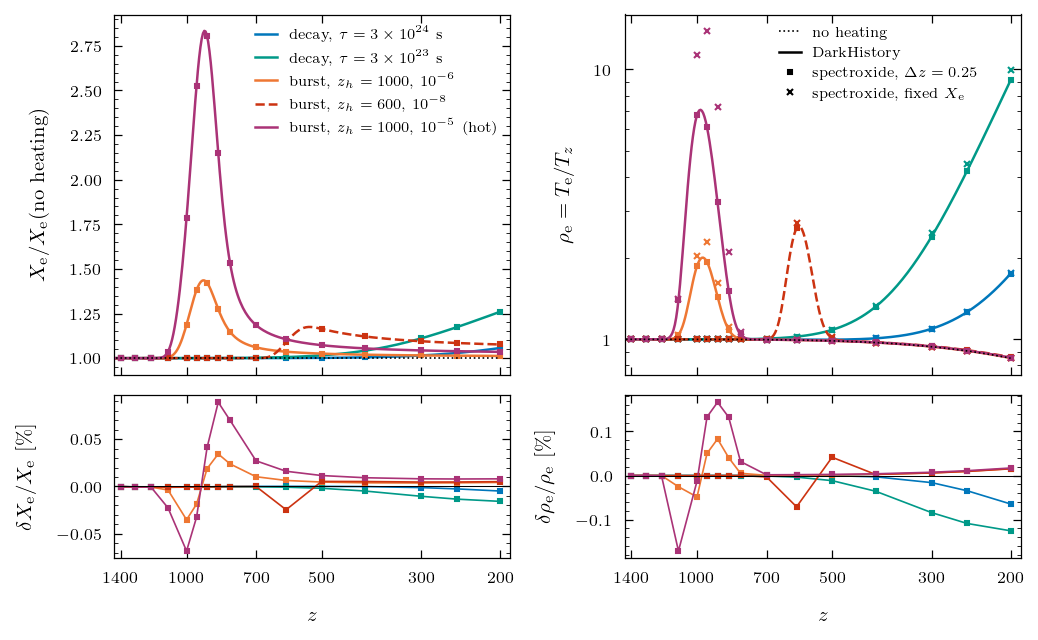

In [6]:
show = ["decay tau=3e24 s", "decay tau=3e23 s", "burst z_h=1000, 1e-6",
        "burst z_h=600, 1e-8", "hot: burst z_h=1000, 1e-5"]
labels = {
    "decay tau=3e24 s": r"decay, $\tau = 3\times10^{24}$ s",
    "decay tau=3e23 s": r"decay, $\tau = 3\times10^{23}$ s",
    "burst z_h=1000, 1e-6": r"burst, $z_h = 1000$, $10^{-6}$",
    "burst z_h=600, 1e-8": r"burst, $z_h = 600$, $10^{-8}$",
    "hot: burst z_h=1000, 1e-5": r"burst, $z_h = 1000$, $10^{-5}$ (hot)",
}
colors = [C["blue"], C["teal"], C["orange"], C["red"], C["purple"]]
styles = ["-", "-", "-", "--", "-"]

fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 0.62 * DOUBLE_COL), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
ax_x, ax_r = axes[0]
ax_xr, ax_rr = axes[1]
for name, col, ls in zip(show, colors, styles):
    r = runs[name]
    ax_x.plot(Z_DH, r["xe_dh_dense"] / xe_dh0_dense, color=col, lw=LW, ls=ls, label=labels[name])
    ax_x.plot(Z_SX, r["xe_fine"] / xe_sx0f, "s", color=col, ms=MS_SMALL - 1)
    ax_r.plot(Z_DH, r["re_dh_dense"], color=col, lw=LW, ls=ls)
    ax_r.plot(Z_SX, r["re_fine"], "s", color=col, ms=MS_SMALL - 1)
    ax_r.plot(Z_SX, r["re_fixed"], "x", color=col, ms=MS_SMALL)
    ax_xr.plot(Z_SX, 100 * (r["xe_fine"] / r["xe_dh"] - 1), "s-", color=col, ms=MS_SMALL - 1,
               lw=LW_THIN)
    ax_rr.plot(Z_SX, 100 * (r["re_fine"] / r["re_dh"] - 1), "s-", color=col, ms=MS_SMALL - 1,
               lw=LW_THIN)
ax_x.plot(Z_DH, xe_dh0_dense / xe_dh0_dense, color="k", lw=LW_THIN, ls=":")
ax_r.plot(Z_DH, re_dh0_dense, color="k", lw=LW_THIN, ls=":", label="no heating")
from matplotlib.ticker import FixedLocator, NullFormatter, NullLocator
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_xlim(1450, 190)
    ax.xaxis.set_major_locator(FixedLocator([1400, 1000, 700, 500, 300, 200]))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:g}")
for ax in (ax_xr, ax_rr):
    ax.axhline(0, color="k", lw=LW_AXIS)
    ax.set_xlabel("$z$")
ax_r.set_yscale("log")
ax_x.set_ylabel(r"$X_\mathrm{e} / X_\mathrm{e}(\mathrm{no\ heating})$")
ax_r.set_ylabel(r"$\rho_\mathrm{e} = T_\mathrm{e}/T_z$")
ax_xr.set_ylabel(r"$\delta X_\mathrm{e}/X_\mathrm{e}$ [\%]")
ax_rr.set_ylabel(r"$\delta\rho_\mathrm{e}/\rho_\mathrm{e}$ [\%]")
ax_x.legend(fontsize=ANNOT_SIZE, loc="upper right", frameon=False)
ax_r.plot([], [], "k-", lw=LW, label="DarkHistory")
ax_r.plot([], [], "ks", ms=MS_SMALL - 1, label="spectroxide, $\\Delta z = 0.25$")
ax_r.plot([], [], "kx", ms=MS_SMALL, label="spectroxide, fixed $X_\\mathrm{e}$")
ax_r.legend(fontsize=ANNOT_SIZE, loc="upper left", bbox_to_anchor=(0.36, 1.0), frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "xe_darkhistory_comparison.pdf", bbox_inches="tight")
plt.show()

## 5. Step-size convergence

The spectroxide–DarkHistory difference at the default steps reaches 0.7% in X_e and 1.2% in
ρ_e for the stronger burst at z_h = 1000. If it is step error, it must shrink with the step
at the design order: the backward-Euler T_e update is first order. Rerun two cases with the
step capped at a ladder of Δz and compare against DarkHistory at rtol = 1e-10. Δz = 0.0625
stores about 2e4 full-spectrum snapshots and can exhaust memory on a 7 GB machine, so the
ladder stops at 0.125.

In [7]:
LADDER = [2.0, 1.0, 0.5, 0.25, 0.125]
ladder = {}
for name in ["burst z_h=1000, 1e-6", "decay tau=3e24 s"]:
    q = SCENARIOS[name]
    xe_d, re_d = dh_history(q, Z_SX, rtol=1e-10)
    rows = [("default", *[float(np.max(np.abs(a / b - 1))) for a, b in
                          zip((runs[name]["xe_sx"], runs[name]["re_sx"]), (xe_d, re_d))])]
    for dz in LADDER:
        xe_s, re_s = sx_history(q, Z_SX, dz_snap=dz)
        rows.append((dz, float(np.max(np.abs(xe_s / xe_d - 1))),
                     float(np.max(np.abs(re_s / re_d - 1)))))
    # first-order extrapolation from the two finest steps: err(dz) = a dz + b
    (d1, x1, r1), (d2, x2, r2) = rows[-2][:3], rows[-1][:3]
    ext = {"xe": x2 - (x1 - x2) / (d1 - d2) * d2, "rho_e": r2 - (r1 - r2) / (d1 - d2) * d2}
    ladder[name] = {"rows": rows, "extrapolated": ext}
    print(f"\n{name}")
    print(f"{'dz':>8} {'max|dXe/Xe|':>12} {'ratio':>6} {'max|drho/rho|':>14} {'ratio':>6}")
    for i, (dz, ex, er) in enumerate(rows):
        rx = rows[i - 1][1] / ex if i > 1 else float("nan")
        rr = rows[i - 1][2] / er if i > 1 else float("nan")
        print(f"{str(dz):>8} {ex:12.3e} {rx:6.2f} {er:14.3e} {rr:6.2f}")
    print(f"  extrapolated to dz -> 0: X_e {ext['xe']:.1e}, rho_e {ext['rho_e']:.1e}")


burst z_h=1000, 1e-6
      dz  max|dXe/Xe|  ratio  max|drho/rho|  ratio
 default    6.893e-03    nan      1.174e-02    nan
     2.0    2.812e-03    nan      6.616e-03    nan
     1.0    1.404e-03   2.00      3.300e-03   2.01
     0.5    7.059e-04   1.99      1.653e-03   2.00
    0.25    3.511e-04   2.01      8.293e-04   1.99
   0.125    1.859e-04   1.89      4.170e-04   1.99
  extrapolated to dz -> 0: X_e 2.1e-05, rho_e 4.8e-06

decay tau=3e24 s
      dz  max|dXe/Xe|  ratio  max|drho/rho|  ratio
 default    2.628e-04    nan      2.811e-03    nan
     2.0    2.300e-04    nan      2.620e-03    nan
     1.0    1.890e-04   1.22      2.578e-03   1.02
     0.5    9.322e-05   2.03      1.289e-03   2.00
    0.25    4.804e-05   1.94      6.442e-04   2.00
   0.125    2.467e-05   1.95      3.223e-04   2.00
  extrapolated to dz -> 0: X_e 1.3e-06, rho_e 3.6e-07


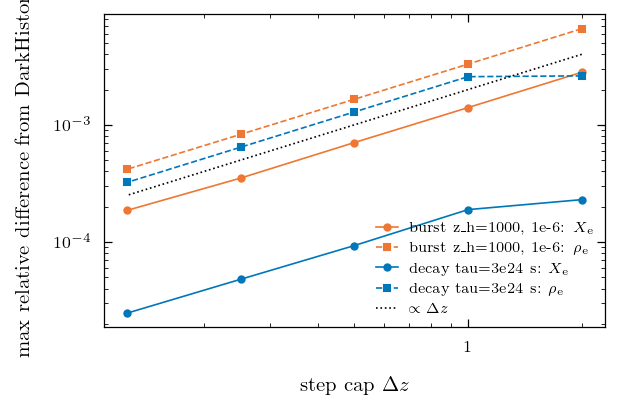

In [8]:
fig, ax = plt.subplots(figsize=(0.6 * DOUBLE_COL, 0.4 * DOUBLE_COL))
for (name, d), col in zip(ladder.items(), [C["orange"], C["blue"]]):
    dz = np.array([r[0] for r in d["rows"][1:]])
    ax.loglog(dz, [r[1] for r in d["rows"][1:]], "o-", color=col, lw=LW_THIN, ms=MS_SMALL,
              label=f"{name}: $X_\\mathrm{{e}}$")
    ax.loglog(dz, [r[2] for r in d["rows"][1:]], "s--", color=col, lw=LW_THIN, ms=MS_SMALL,
              label=f"{name}: $\\rho_\\mathrm{{e}}$")
ax.loglog(dz, 2e-3 * dz, "k:", lw=LW_THIN, label=r"$\propto \Delta z$")
ax.set_xlabel(r"step cap $\Delta z$")
ax.set_ylabel("max relative difference from DarkHistory")
ax.legend(fontsize=ANNOT_SIZE, frameon=False)
fig.tight_layout()
plt.show()

## 6. DarkHistory tolerance

The `fine` columns above rerun spectroxide with its step capped at Δz = 0.25, twenty times
below the default 0.005 z at z = 1000; the change measures spectroxide's step error. Here
DarkHistory's LSODA tolerance is checked the same way: rerun the strongest non-hot case at
rtol = 1e-11.

In [9]:
name = "burst z_h=600, 1e-8"
xe_t, re_t = dh_history(SCENARIOS[name], Z_SX, rtol=1e-11)
dh_tol = {"xe": float(np.max(np.abs(xe_t / runs[name]["xe_dh"] - 1))),
          "rho_e": float(np.max(np.abs(re_t / runs[name]["re_dh"] - 1)))}
print("DarkHistory rtol 1e-9 vs 1e-11:", dh_tol)

DarkHistory rtol 1e-9 vs 1e-11: {'xe': 1.9716618804288544e-07, 'rho_e': 2.6085297921696338e-08}


## 7. Save

In [10]:
out = {
    "physics_hash": PHYSICS_HASH,
    "darkhistory_version": "1.1.2 (PyPI)",
    "cosmology": CD,
    "z_start": Z_START,
    "z_sx": Z_SX.tolist(),
    "null": null_summary,
    "heated": summary,
    "darkhistory_rtol_check": dh_tol,
    "dz_fine": DZ_FINE,
    "step_ladder": ladder,
}
DATA_OUT.write_text(json.dumps(out, indent=2))
print(json.dumps({k: out[k] for k in ["null", "darkhistory_rtol_check"]}, indent=2))
for k, v in summary.items():
    print(f"{k:28s} Xe {v['max_abs_dxe_rel']:.1e}  rho_e {v['max_abs_drho_e_rel']:.1e}  "
          f"resp Xe {v['response_err_xe']:.1e}  resp rho_e {v['response_err_rho_e']:.1e}  "
          f"(fixed {v['response_err_rho_e_fixed']:.1e})  fine: Xe {v['fine_max_abs_dxe_rel']:.1e} "
          f"resp Xe {v['fine_response_err_xe']:.1e} resp rho_e {v['fine_response_err_rho_e']:.1e}")

{
  "null": {
    "max_abs_dxe_rel": 0.00013709058808886176,
    "max_abs_drho_e": 0.0005892058162455527,
    "fine_max_abs_dxe_rel": 2.0857128636420086e-05,
    "fine_max_abs_drho_e": 0.00013019329618946252,
    "max_abs_atomic_model_dxe_rel": 0.00721756282380015,
    "table_dxe_rel_at_200": 0.021953910971773016
  },
  "darkhistory_rtol_check": {
    "xe": 1.9716618804288544e-07,
    "rho_e": 2.6085297921696338e-08
  }
}
decay tau=3e24 s             Xe 2.6e-04  rho_e 2.8e-03  resp Xe 7.2e-03  resp rho_e 6.1e-03  (fixed 8.3e-03)  fine: Xe 4.8e-05 resp Xe 1.2e-03 resp rho_e 1.4e-03
decay tau=3e23 s             Xe 1.1e-03  rho_e 5.6e-03  resp Xe 5.3e-03  resp rho_e 5.9e-03  (fixed 9.5e-02)  fine: Xe 1.6e-04 resp Xe 7.7e-04 resp rho_e 1.4e-03
burst z_h=1000, 1e-7         Xe 1.3e-03  rho_e 2.4e-03  resp Xe 2.3e-02  resp rho_e 2.1e-02  (fixed 5.5e-02)  fine: Xe 7.4e-05 resp Xe 1.1e-03 resp rho_e 1.4e-03
burst z_h=1000, 1e-6         Xe 6.9e-03  rho_e 1.2e-02  resp Xe 2.0e-02  resp rho_e 1.8e